# Step 1 (V20): Aggressive Bullish Weighted XGBoost (Fixed Threshold)

## 🎯 Objective:
Meningkatkan agresivitas **Prediksi 1 (Bullish)** dengan beban berat, namun tetap menjaga kualitas dengan **Threshold 0.59**.

## ⚖️ Strategy: Manual Scale Positive Weight + Custom Threshold
1. **BULL_BOOST (2.0)**: Memaksa model mempelajari pola Bullish lebih dalam.
2. **THRESHOLD (0.59)**: Hanya mengeluarkan sinyal jika probabilitas Bullish > 59%.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V20 Aggressive (0.59 Threshold) Ready")

✅ V20 Aggressive (0.59 Threshold) Ready


## 1. Feature Engineering

In [22]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['RSI_14'] = calculate_rsi(market_return, 14)
features['Ret_Lag1'] = market_return.shift(1)
features['Vol_Shift'] = features['Vol_20'].pct_change()
features['Target'] = (market_return.rolling(window=5).mean().shift(-5) > 0).astype(int)

features = features.replace([np.inf, -np.inf], np.nan).dropna()

X = features.drop('Target', axis=1)
y = features['Target']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

print(f"📌 Train Class Distribution:\n{y_train.value_counts()}")

📌 Train Class Distribution:
Target
1    348
0    243
Name: count, dtype: int64


## 2. Training with Manual Boost

In [23]:
BULL_BOOST_FACTOR = 2.0 

xgb_aggressive = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=BULL_BOOST_FACTOR 
)

xgb_aggressive.fit(X_train, y_train)
print(f"🚀 Aggressive Model Trained (Boost: {BULL_BOOST_FACTOR})")

🚀 Aggressive Model Trained (Boost: 2.0)


## 3. Evaluation with Threshold 0.59

--- Aggressive Model Results (Threshold: 0.4) ---
Recall: 0.9474
Precision: 0.5294

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.09      0.15       175
           1       0.53      0.95      0.68       190

    accuracy                           0.53       365
   macro avg       0.56      0.52      0.41       365
weighted avg       0.56      0.53      0.43       365



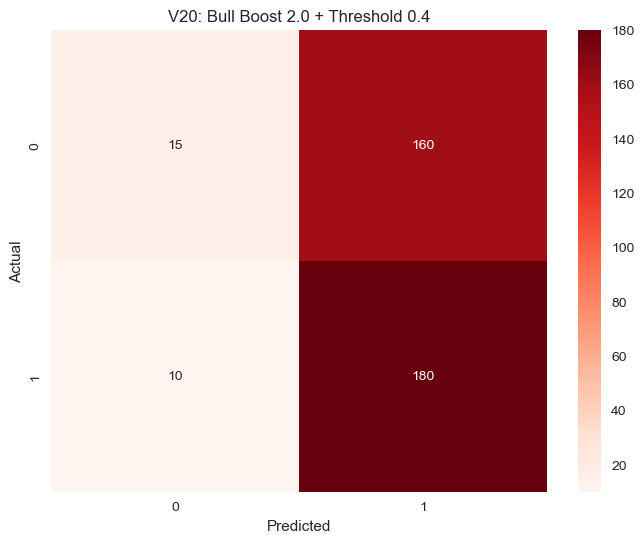

In [24]:
# Ambil probabilitas
probs = xgb_aggressive.predict_proba(X_test)[:, 1]

# Terpakan Threshold Disiplin 0.59
CUSTOM_THRESHOLD = 0.4
preds_custom = (probs >= CUSTOM_THRESHOLD).astype(int)

cm = confusion_matrix(y_test, preds_custom)

print(f"--- Aggressive Model Results (Threshold: {CUSTOM_THRESHOLD}) ---")
print(f"Recall: {recall_score(y_test, preds_custom):.4f}")
print(f"Precision: {precision_score(y_test, preds_custom):.4f}")
print("\nClassification Report:\n", classification_report(y_test, preds_custom))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title(f"V20: Bull Boost {BULL_BOOST_FACTOR} + Threshold {CUSTOM_THRESHOLD}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()